# Problem 1 - Multiples of 3 or 5
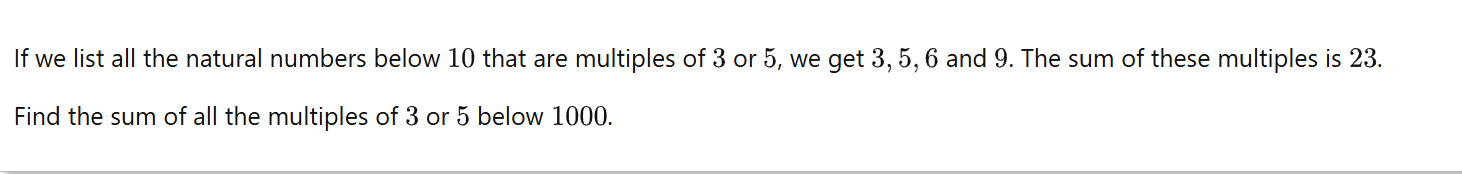

In [60]:
def euler1(maks):
    sum = 0
    for i in range(maks):
        if (i % 3 == 0 or i % 5 == 0) and i != 0:
            sum += i
    print(sum)

euler1(1000)

233168


Aritmetisk sum, simplere løsning:  
$$
\text{Sum} = \frac{n \cdot (a + l)}{2}
$$
Hvor:  
$a$ er det første element  
$l$ er det sidste element  
$n$ er antal elementer

In [61]:
def euler1(maks):
    tal = maks-1
    n_treere = tal // 3
    n_femere = tal // 5
    n_femtenere = tal // 15
    sum3 = (n_treere * (3 + n_treere*3))/2
    sum5 = (n_femere * (5 + n_femere*5))/2
    sum15 = (n_femtenere * (15 + n_femtenere*15))/2
    return sum3+sum5-sum15

euler1(1000)

233168.0

# Problem 2 - Even Fibonacci Numbers
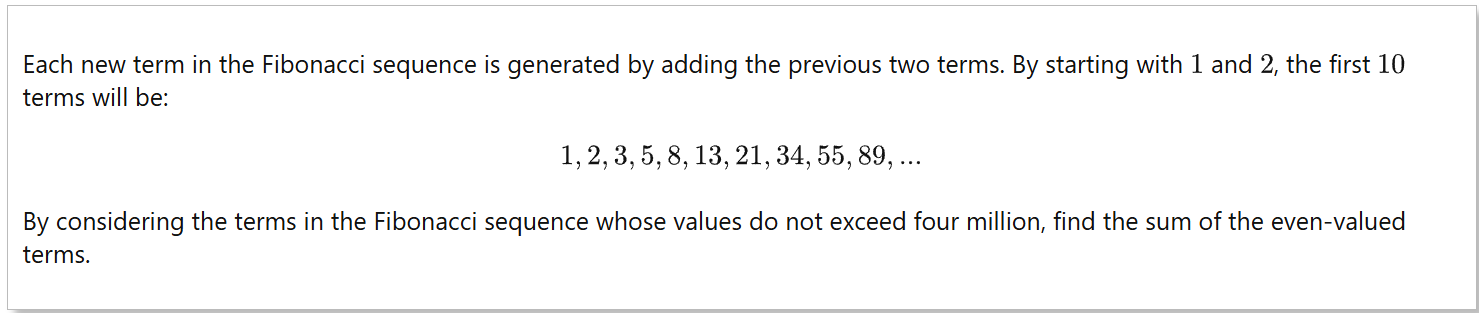

In [ ]:
def euler2(maks):
    import math
    golden_ratio = (1+math.sqrt(5))/(2)
    new_fibo = 1
    sum = 0

    while new_fibo < maks:
        result = golden_ratio * new_fibo #3
        new_fibo = round(result)

        if new_fibo <= maks and new_fibo % 2 == 0:
            sum += new_fibo

    return sum

 
euler2(4_000_000)

4613732

# Problem 3 - Largest Prime Factor
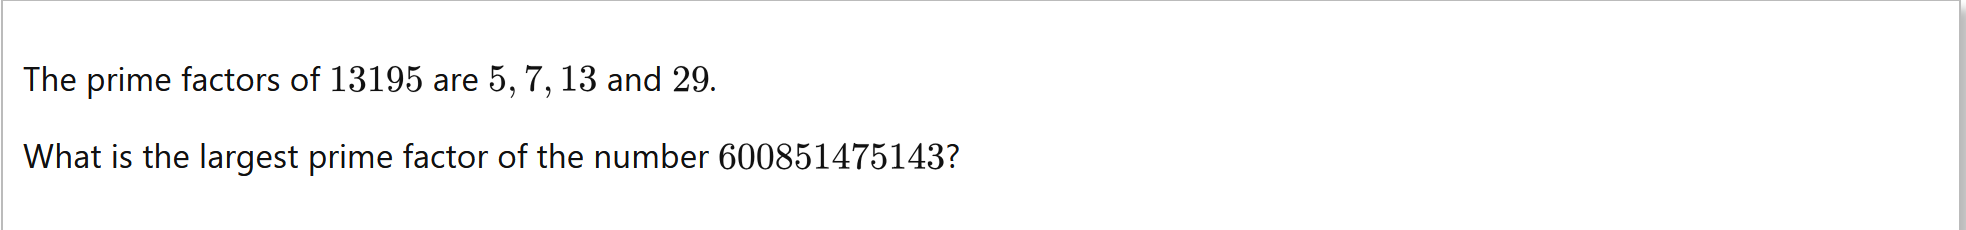

In [2]:
def euler3(orig_tal):
    import math
    d = 2
    prime_f = []
    tal = orig_tal
    while d < round(math.sqrt(orig_tal)):
        if tal % d == 0:
            tal = tal / d
            prime_f.append(d)
            d += 1
        else:
            d += 1
            
    print(prime_f)

euler3(13195)

[5, 7, 13, 29]


# Problem 4 - Largest Prime Factor

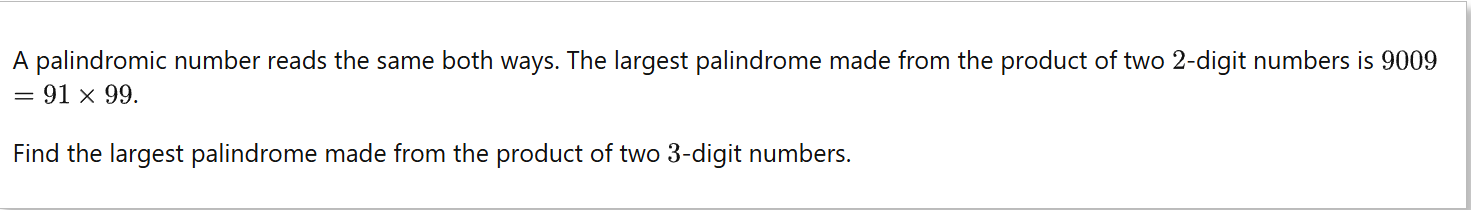

In [15]:
def euler4(digits):
    if digits == 1 or digits > 4:
        print("Choose digits: 2, 3") # Kun 2,3 digits andet er for stort at udregne. 4 digits = 54 sek
        return
    
    dict = {1:9, 2:99, 3:999, 4:9999, 5:99999}
    palind_kandidat = []
    palind = []

    for i in range(dict[digits], dict[digits-1], -1):     #Tal 1
        for j in range(dict[digits], dict[digits-1], -1): #Tal 2
            palind_kandidat.append(str(i*j))              #Produkter af tal 1 og 2, en string

    for k in list(range(len(palind_kandidat))): # Gå gennem palindrom kandidater
        if palind_kandidat[k][0:digits] == palind_kandidat[k][digits*2:digits-1:-1]: # Hvis første halvdel af palind
            palind.append(palind_kandidat[k])                                        # == anden halvdel = PALINDROM

    return sorted(palind, reverse=True)[0]  #Højest mulige palindrom af produkt
euler4(3)

'906609'

Ovenstående er meget ineffektivt, herunder er bedre løsning:

In [16]:
def palindrom(n):                       # Seperat tjek
    n_string = str(n)
    return n_string == n_string[::-1]

def euler4(digits):
    max = 10**digits - 1
    min = 10**(digits - 1)
    
    best = 0
    for i in range(max, min-1, -1):     
        if i * max <= best:             # Ingen grund til at tjekke flere (lavere) i, hvis best er fundet
            break
        for j in range(i, min-1, -1):   # Tjekker direkte fra max = i, undgår duplikater
            produkt = i * j
            if produkt <= best:         # Ingen grund til at tjekke flere (lavere) j, hvis best er fundet
                break
            if palindrom(produkt):
                best = produkt
    
    return best

euler4(3)

906609

# Problem 5 - Smallest Multiple
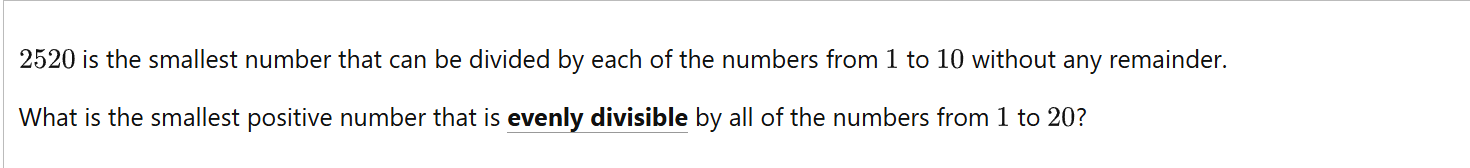

Ide er at jeg vil gange et tal fra 1 til 20, sammen 20 gange, og tjekke om alle

In [ ]:
def euler5():
    found = False
    number = 20
    even_divisible = 0
    
    while not found:
        for i in list(range(2, 21)):
            if number % i == 0:
                even_divisible += 1
            if even_divisible == 19:
                found = True
                break
        number += 1
        even_divisible = 0
    return number

euler5()

21

In [57]:
def euler5():
    number = 1
    even_divisible = 0
    while True:
        for i in [2,3,5,7,11,13,17,19]:
            if number % i == 0:
                even_divisible += 1
            if even_divisible == 8:
                return number
        number += 1
        even_divisible = 0

euler5()

9699690

# Problem 6 - Sum Square Difference
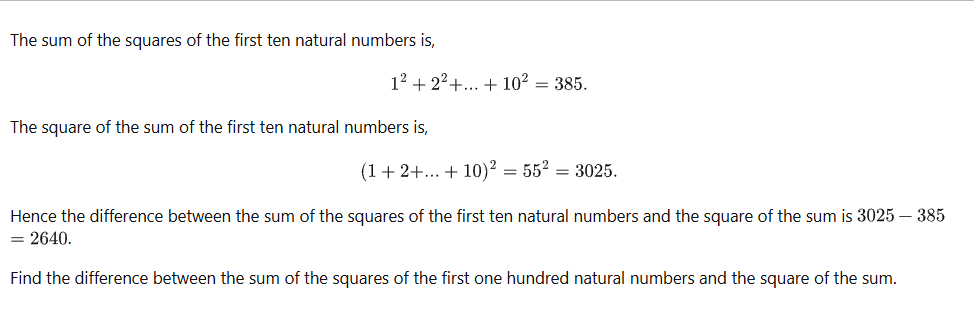

In [63]:
def euler6(numbers):
    sum_squares = 0
    squares_sum = 0
    for i in range(numbers):
        sum_squares += (i+1)**2
        squares_sum += (i+1)

    return squares_sum**2 - sum_squares

euler6(1000)

250166416500

eller

In [62]:
def euler6(numbers):
    return sum(range(numbers+1))**2 - sum([x**2 for x in range(numbers+1)])

euler6(1000)

250166416500

Kvadrat af sum er nemt da man allerede har udtryk for aritmetisk sum, men sum af kvadrater er anderledes og dette udtryk dækker det:
$$
\text{Sum af kvadrater} = \frac{n(n+1)}{2} \frac{(2n+1)}{3}
$$

In [77]:
def euler6(numbers):
    sum_kvadrater = ((numbers * (numbers + 1))/2) * ((2*numbers + 1)/3)
    kvadrater_sum = (numbers*(numbers + 1))/(2)
    return kvadrater_sum**2 - sum_kvadrater

euler6(100)

25164150.0

# Problem 7 - 10 001st Prime
